In [3]:
import numpy as np
from matplotlib import pyplot as plt
import tqdm

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

from polychrom.hdf5_format import HDF5Reporter, list_URIs, load_URI, load_hdf5_file, save_hdf5_file
from polychrom.contactmaps import monomerResolutionContactMapSubchains


In [8]:
output_folder = '/mnt/md1/jjusuf/polysim/outputs/trajectory_LEF_EP_absquant_region_bootcamp_version'
files = list_URIs(output_folder)

print(f'{len(files)} saved blocks found')


360000 saved blocks found


In [13]:
# Make a contact matrix (simulated Micro-C)

region_size = 2000  # 2000 kb = 2 Mb
num_regions = 35    # the region repeats 35 times across the entire chromosome
region_starts = np.arange(num_regions) * region_size

block_start = 180000
block_end = 360000
block_step = 1000

files_to_use = files[block_start:block_end:block_step]
print(len(files_to_use))  # as a rule of thumb, don't exceed a few hundred


180


In [14]:
cutoff = 2  # when two monomers have a 3D distance below this cutoff, they are considered a "contact"
nproc = 4   # number of threads to use

contact_mat = monomerResolutionContactMapSubchains(filenames=files_to_use,
                                                   mapStarts=region_starts,
                                                   mapN=region_size,
                                                   cutoff=cutoff,
                                                   n=nproc)


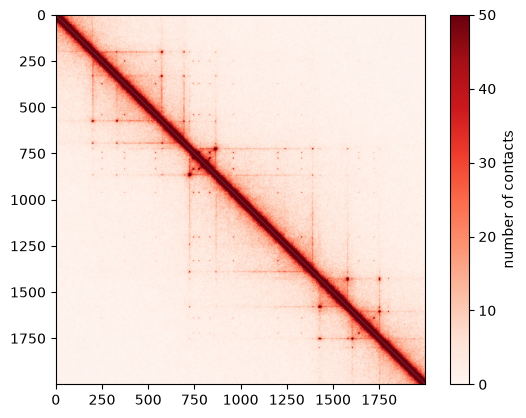

In [23]:
plt.imshow(contact_mat, cmap='Reds', vmin=0, vmax=50);
plt.colorbar(label='number of contacts');
